# Pre-Processing the data

In [1]:
import os
import zipfile
import random
import shutil
import numpy as np

# 1. Baixa o dataset oficial (Hospedado pela Microsoft)
!wget --no-check-certificate \
    "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip" \
    -O /tmp/cats_and_dogs.zip

# 2. Extrai o arquivo principal
zip_ref = zipfile.ZipFile('/tmp/cats_and_dogs.zip', 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

# 3. Recria a estrutura de pastas idêntica à do "filtered" original
base_dir = '/tmp/cats_and_dogs_filtered'
for split in ['train', 'validation']: #aqui temos as imagens divididas em treino e validação
    for classe in ['cats', 'dogs']: #em cada pasta de treino e validação temos uma pasta de gatos e cachorros
        os.makedirs(os.path.join(base_dir, split, classe), exist_ok=True)

# 4. Função para embaralhar e separar um limite de fotos (1000 Treino / 500 Validação)
def split_data(SOURCE, TRAINING, VALIDATION):
    files = []
    for filename in os.listdir(SOURCE):
        file = os.path.join(SOURCE, filename)
        # Ignora arquivos corrompidos (comum em datasets reais)
        if os.path.getsize(file) > 0 and filename.endswith('.jpg'):
            files.append(filename)

    # Embaralha as imagens
    shuffled_set = random.sample(files, len(files))

    # Pega apenas 1500 imagens de cada classe para ficar idêntico ao tutorial antigo
    for i, filename in enumerate(shuffled_set[:1500]):
        src = os.path.join(SOURCE, filename)
        if i < 1000:
            shutil.copyfile(src, os.path.join(TRAINING, filename))
        else:
            shutil.copyfile(src, os.path.join(VALIDATION, filename))

# Caminhos de origem (como a Microsoft nomeia)
CAT_SOURCE_DIR = "/tmp/PetImages/Cat/"
DOG_SOURCE_DIR = "/tmp/PetImages/Dog/"

# Caminhos de destino (como o seu código espera)
TRAIN_CATS_DIR = os.path.join(base_dir, "train/cats/")
VAL_CATS_DIR = os.path.join(base_dir, "validation/cats/")
TRAIN_DOGS_DIR = os.path.join(base_dir, "train/dogs/")
VAL_DOGS_DIR = os.path.join(base_dir, "validation/dogs/")

split_data(CAT_SOURCE_DIR, TRAIN_CATS_DIR, VAL_CATS_DIR)
split_data(DOG_SOURCE_DIR, TRAIN_DOGS_DIR, VAL_DOGS_DIR)



--2026-06-08 21:58:40--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 184.28.149.199, 2600:1406:5e00:392::317f, 2600:1406:5e00:389::317f
Connecting to download.microsoft.com (download.microsoft.com)|184.28.149.199|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘/tmp/cats_and_dogs.zip’

/tmp/cats_and_dogs. 100%[===================>] 786.67M   135MB/s    in 5.4s    

2026-06-08 21:58:46 (145 MB/s) - ‘/tmp/cats_and_dogs.zip’ saved [824887076/824887076]



# Creating DataSet and DataLoader

In [3]:
import torch
from torchvision import datasets, transforms as T
from torch.utils.data import DataLoader

base_dir = '/tmp/cats_and_dogs_filtered'
train_dir = f"{base_dir}/train"
val_dir = f"{base_dir}/validation"

prep_transform = T.Compose(
    [
        T.ToTensor(),
        # T.Normalize(
        #     (0.4914, 0.4822, 0.4465),
        #     (0.2470, 0.2435, 0.2616)
        # ),
        T.Resize(size=(180,180)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=(0,105))
    ]
)

# O ImageFolder junta automaticamente as subpastas e cria as classes (0 e 1)
train_dataset = datasets.ImageFolder(root=train_dir, transform=prep_transform) #é uma matriz, na qual cada elemento dela é uma tupla, na qual o primeiro elemento é um Tensor e o Segundo um número inteiro
val_dataset = datasets.ImageFolder(root=val_dir, transform=prep_transform)

train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
validate_dataloader = DataLoader(val_dataset,batch_size=32, shuffle=True)
print(train_dataloader)


# Data Augmentation

## Functions and imports

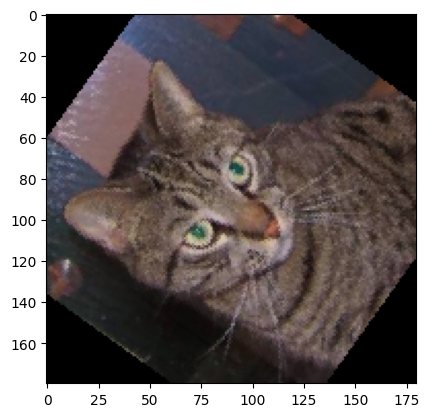

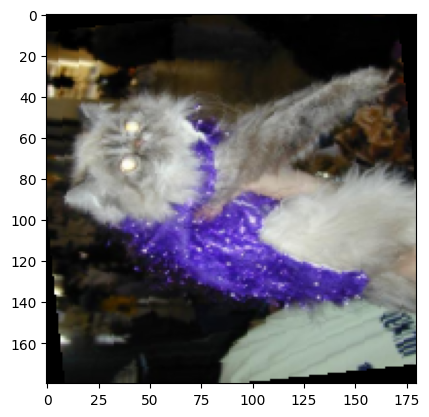

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt


def Load_Image(dataset):
  image_tensor1, rotulo1 = dataset[0]
  image_tensor2, rotulo2 = dataset[1]
  return image_tensor1, image_tensor2

img1, img2= Load_Image(train_dataset)

def NormalShowImage(Image):
  chang_image = Image.permute(1,2,0)
  plt.imshow(chang_image)
  plt.show()

NormalShowImage(img1)
NormalShowImage(img2)

def ShowImage(Image):
  plt.imshow(Image)
  plt.show()

## Random Flip

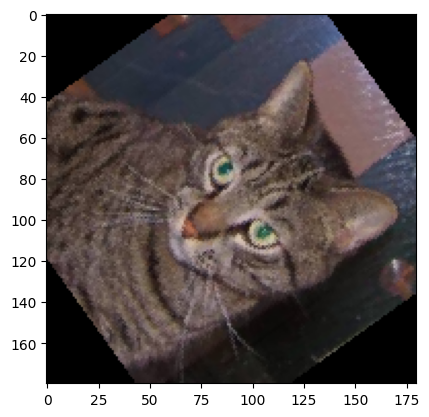

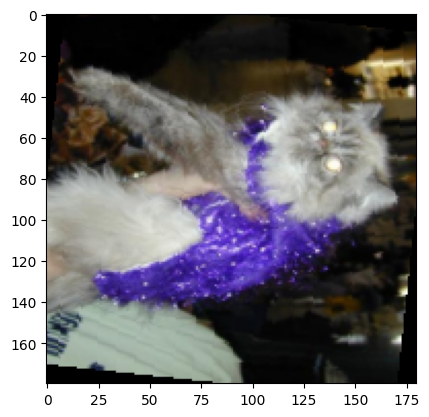

In [5]:
Horizontal_Flipping_Transformation = T.Compose([
    T.ToPILImage(),
    T.RandomHorizontalFlip(p=0.5)
])

Flipping_Img = Horizontal_Flipping_Transformation(img1)
ShowImage(Flipping_Img)
Flipping_Img2 = Horizontal_Flipping_Transformation(img2)
ShowImage(Flipping_Img2)

## Rotation

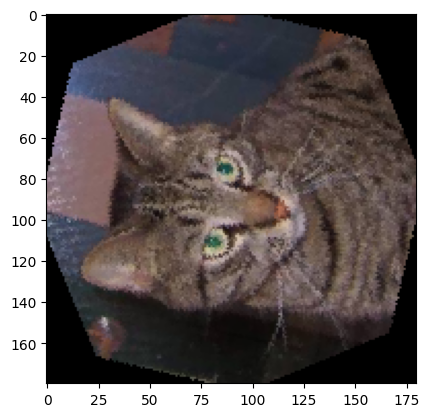

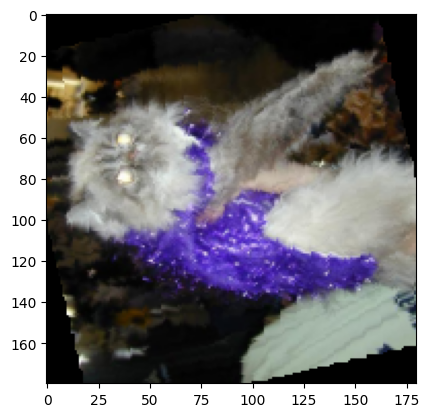

In [6]:
Rotate_Transformation = T.Compose([
    T.ToPILImage(),
    T.RandomRotation(degrees=(0,105))
])
rotate1 = Rotate_Transformation(img1)
rotate2 = Rotate_Transformation(img2)
ShowImage(rotate1)
ShowImage(rotate2)

# Building the NN

In [20]:
import torch
from torch import nn

In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [22]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten = nn.Flatten()
    self.convlayer = nn.Sequential( #padding diz que a imagem perderá as bordas pois a matriz de kernel não estará centrada nas pontas da imagem (matriz)
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size= (3,3), padding = 1),
        nn.BatchNorm2d(num_features=32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)), #diminui a matriz para uma matriz de 2x2, pega o maior elemento de cada quadrante para tentar manter a informação
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size= (3,3), padding = 1),
        nn.BatchNorm2d(num_features=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2)),
        nn.Conv2d(in_channels=64, out_channels=64, kernel_size= (3,3), padding = 1),
        nn.BatchNorm2d(num_features=64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2))
    )

    self.linear = nn.Sequential(
        nn.Linear(30976,256),
        nn.Dropout(p = 0.4),
        nn.ReLU(),
        nn.Linear(256,2)
    )

  def forward(self,x):
    v = self.convlayer(x)
    v = self.flatten(v)
    return self.linear(v)

In [23]:
conv_model = CNN().to(device)
conv_optim = torch.optim.SGD(conv_model.parameters(), lr = 0.001)
lossfunc = nn.CrossEntropyLoss()


In [24]:
def train(model, dataloader, loss_func, optimizer):
  model.train()
  cumloss = 0.0
  total_imagens = 0
  acertos = 0

  for imgs, labels in dataloader:
    # print(imgs)
    # print(f'Labels: {labels}')

    imgs, labels = imgs.to(device), labels.to(device)
    pred = model(imgs)

    loss = loss_func(pred, labels)
    #zera os gradientes acumulados
    optimizer.zero_grad()
    #computa os gradientes
    loss.backward()
    # anda no sentido de diminuir o gradiente, ou seja, reduz o erro local
    optimizer.step()

    cumloss += loss.item()

    decided = torch.argmax(pred,1)
    acertos += (decided == labels).sum().item()
    total_imagens += labels.size(0)
  acuracia = acertos/total_imagens

  return cumloss/len(dataloader), acuracia

def test(model, dataloader, lossfunc):
  cumloss = 0.0
  acertos = 0
  total_imagens = 0
  accu_array = []
  loss_array = []
  model.eval()
  with torch.no_grad():
    for imgs, labels in dataloader:
      imgs, labels = imgs.to(device), labels.to(device)
      pred = model(imgs)
      loss = lossfunc(pred, labels)

      cumloss += loss.item()
      decided = torch.argmax(pred, 1)
      acertos += (decided == labels).sum().item()
      total_imagens += labels.size(0)
    acuracia = acertos/total_imagens

    return cumloss/len(dataloader), acuracia


In [25]:
epochs = 20
loss_arr_train = []
accu_array_train = []
loss_arr_vali = []
accu_arry_vali = []
for t in range(1,epochs + 1):
  train_loss, train_accu = train(conv_model,train_dataloader,lossfunc,conv_optim)
  vali_loss, vali_accu = test(conv_model,validate_dataloader,lossfunc)
  loss_arr_train.append(train_loss)
  accu_array_train.append(train_accu)
  loss_arr_vali.append(vali_loss)
  accu_arry_vali.append(vali_accu)
  if (t % 10 == 0):
    print(f'Epoch {t} - Train Accuracy {train_accu} Validate Accuracy {vali_accu}')

Epoch 10 - Train Accuracy 0.672 Validate Accuracy 0.686
Epoch 20 - Train Accuracy 0.711 Validate Accuracy 0.703


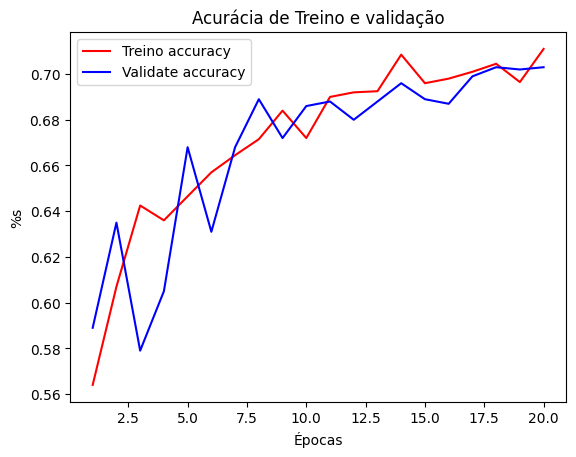

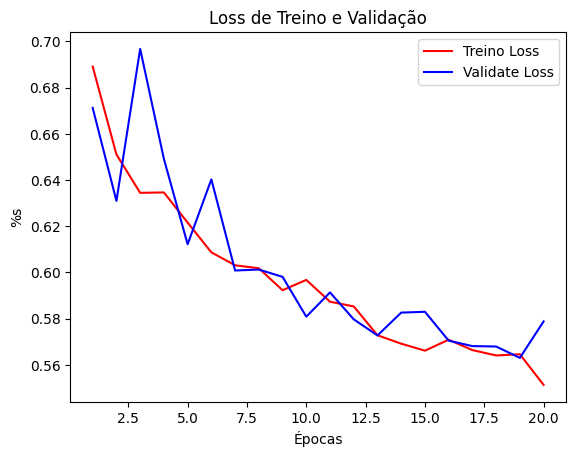

In [26]:

final = 21
epoch = range(1, final)
plt.plot(epoch, accu_array_train, "r", label="Treino accuracy")
plt.plot(epoch, accu_arry_vali, "b", label="Validate accuracy")
plt.xlabel("Épocas")
plt.ylabel("%s")
plt.title("Acurácia de Treino e validação")
plt.legend()
plt.figure()

#plota os gráficos da loss
plt.plot(epoch, loss_arr_train, "r", label = "Treino Loss")
plt.plot(epoch, loss_arr_vali, "b", label = "Validate Loss")
plt.xlabel("Épocas")
plt.ylabel("%s")
plt.title("Loss de Treino e Validação")
plt.legend()
plt.show()